<a href="https://www.kaggle.com/code/rithikhchandran/notebookdfcd8cdb79?scriptVersionId=337372825" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Cell 1 — Install TRIBE v2 and dependencies
!git clone https://github.com/facebookresearch/tribev2.git
%cd tribev2
!pip install -e . -q
!pip install -e ".[plotting]" -q   # adds brain-visualization deps (nilearn etc.)

Cloning into 'tribev2'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 68 (delta 23), reused 9 (delta 9), pack-reused 14 (from 3)
Receiving objects: 100% (68/68), 3.49 MiB | 20.89 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/kaggle/working/tribev2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.0 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.1/258.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 6.

In [2]:
# Cell 2 — HuggingFace login
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(token=hf_token)
print("Logged in to HuggingFace.")

Logged in to HuggingFace.


In [3]:
# Cell 3 (updated) — Find audio, then COPY it to a writable location
import glob, os, shutil

candidates = glob.glob("/kaggle/input/datasets/rithikhchandran/version-3-0-2-4/song10.wav", recursive=True)
audio_files = [f for f in candidates if f.lower().endswith((".wav", ".mp3", ".flac", ".m4a", ".ogg"))]
print("Audio files found:", audio_files)

src = audio_files[0]   # or hard-code your exact input path

# Copy into writable working dir so TRIBE can write its transcript .tsv alongside it
work_dir = "/kaggle/working/audio_in"
os.makedirs(work_dir, exist_ok=True)
AUDIO_PATH = os.path.join(work_dir, os.path.basename(src))
shutil.copy(src, AUDIO_PATH)

print("Using writable copy:", AUDIO_PATH)

Audio files found: ['/kaggle/input/datasets/rithikhchandran/version-3-0-2-4/song10.wav']
Using writable copy: /kaggle/working/audio_in/song10.wav


In [4]:
# Cell 4 (unchanged logic) — Load TRIBE v2 and run inference
import torch
from tribev2 import TribeModel

print("CUDA available:", torch.cuda.is_available())

model = TribeModel.from_pretrained("facebook/tribev2", cache_folder="./cache")

df = model.get_events_dataframe(audio_path=AUDIO_PATH)
print("Events dataframe shape:", df.shape)

preds, segments = model.predict(events=df)
print("Predictions shape:", preds.shape)

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-07-23 09:04:51 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


CUDA available: True


config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

2026-07-23 09:04:58 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:461: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
Extracting words from audio: 100%|██████████| 1/1 [01:42<00:00, 102.53s/it]
No tran

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[09:07:07 INFO] Preparing extractor: subject_id
2026-07-23 09:07:07 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[09:07:08 INFO] Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:01<00:00,  1.09s/it]
INFO - Predicted 45 / 100 segments (45.0% kept)


Predictions shape: (45, 20484)


In [5]:
# Cell 5 — Save predictions
import numpy as np

np.save("/kaggle/working/brain_predictions.npy", preds)
print("Saved to /kaggle/working/brain_predictions.npy")
print("Shape:", preds.shape, "| min:", preds.min(), "max:", preds.max())

Saved to /kaggle/working/brain_predictions.npy
Shape: (45, 20484) | min: -0.5307143 max: 0.4644171


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7b12a434e660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-32a4b2

Saved brain_left.png and brain_right.png


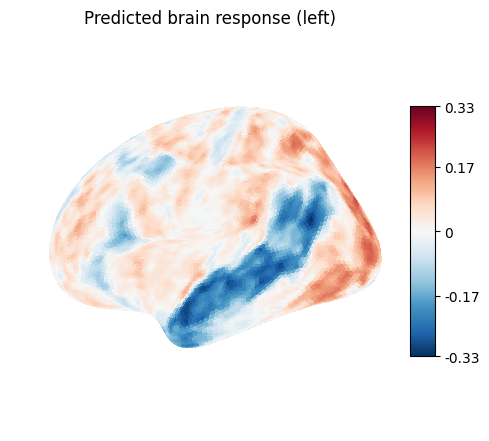

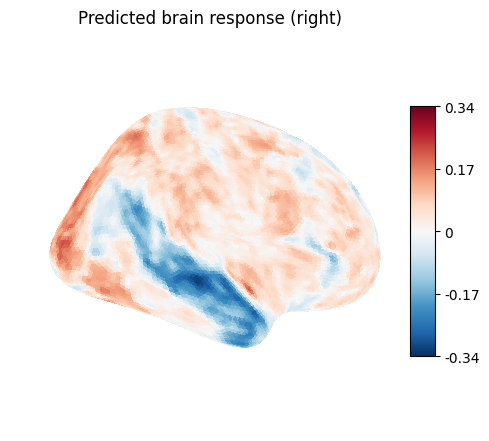

In [6]:
# Cell 6 — Brain visualization
import numpy as np
from nilearn import datasets, plotting

mean_response = preds.mean(axis=0)   # average across time → (n_vertices,)

fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")
n = mean_response.shape[0]
half = n // 2

plotting.plot_surf_stat_map(
    fsaverage.infl_left, mean_response[:half],
    hemi="left", title="Predicted brain response (left)",
    colorbar=True, bg_map=fsaverage.sulc_left,
).savefig("/kaggle/working/brain_left.png", dpi=150)

plotting.plot_surf_stat_map(
    fsaverage.infl_right, mean_response[half:],
    hemi="right", title="Predicted brain response (right)",
    colorbar=True, bg_map=fsaverage.sulc_right,
).savefig("/kaggle/working/brain_right.png", dpi=150)

print("Saved brain_left.png and brain_right.png")

In [7]:
# Cell A — audio + GIF libraries
!pip install librosa imageio -q

Loaded audio: 45.00s @ 48000 Hz


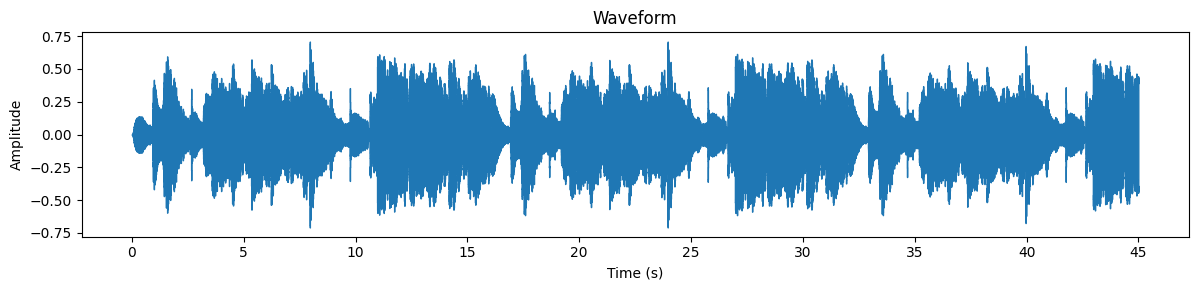

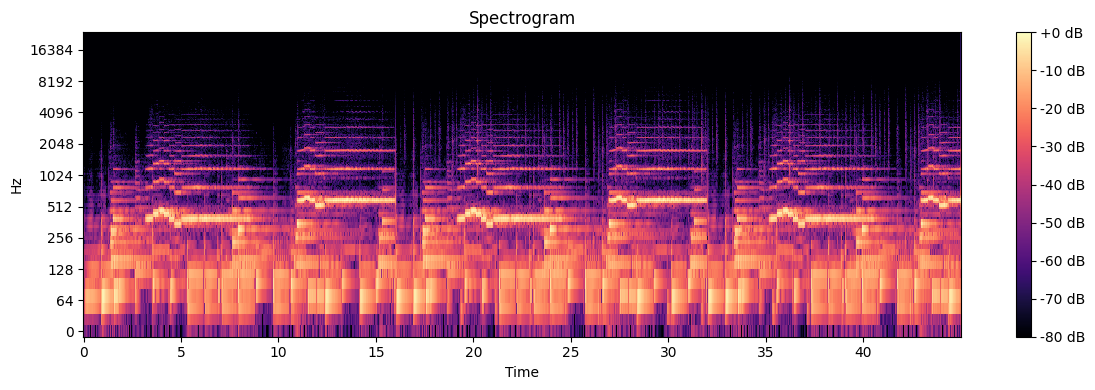

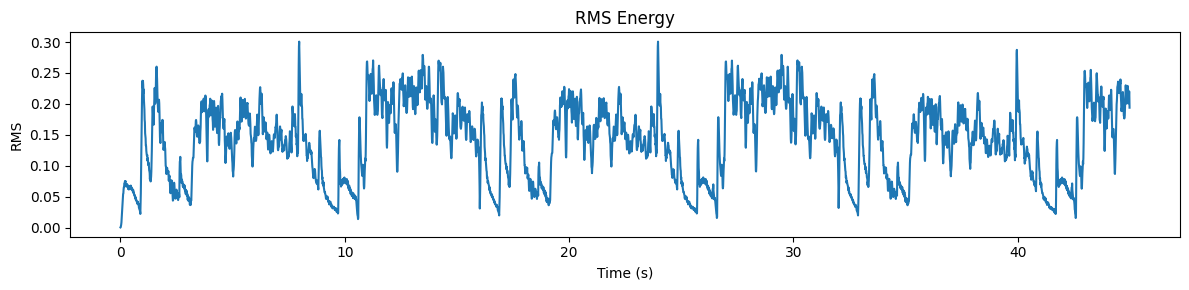

Saved waveform.png, spectrogram.png, rms.png, rms_raw.npy


In [8]:
# Cell B — Audio analysis: waveform, spectrogram, RMS
import numpy as np
import librosa, librosa.display
import matplotlib.pyplot as plt

OUT = "/kaggle/working"

y, sr = librosa.load(AUDIO_PATH, sr=None, mono=True)
duration = len(y) / sr
print(f"Loaded audio: {duration:.2f}s @ {sr} Hz")

# --- Waveform ---
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform"); plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.tight_layout(); plt.savefig(f"{OUT}/waveform.png", dpi=150); plt.show()

# --- Spectrogram (dB) ---
S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
plt.figure(figsize=(12, 4))
librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB"); plt.title("Spectrogram")
plt.tight_layout(); plt.savefig(f"{OUT}/spectrogram.png", dpi=150); plt.show()

# --- RMS energy envelope ---
hop = 512
rms = librosa.feature.rms(y=y, hop_length=hop)[0]
rms_t = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop)
plt.figure(figsize=(12, 3))
plt.plot(rms_t, rms)
plt.title("RMS Energy"); plt.xlabel("Time (s)"); plt.ylabel("RMS")
plt.tight_layout(); plt.savefig(f"{OUT}/rms.png", dpi=150); plt.show()

np.save(f"{OUT}/rms_raw.npy", np.vstack([rms_t, rms]))
print("Saved waveform.png, spectrogram.png, rms.png, rms_raw.npy")

In [9]:
# Cell C — Raw brain reaction, per-timestep metrics, timestamps
import numpy as np, pandas as pd

preds = np.asarray(preds)            # (n_timesteps, n_vertices)
n_t, n_v = preds.shape
print("preds shape:", preds.shape)

# --- reaction_raw: save the full prediction matrix ---
np.save(f"{OUT}/reaction_raw.npy", preds)

# --- brain timestamps ---
# TRIBE predicts at the fMRI sampling rate, offset 5s into the past for hemodynamic lag.
# Try to read true timing from `segments`; otherwise space evenly across audio duration.
try:
    seg = pd.DataFrame(segments)
    if "onset" in seg.columns:
        timestamps = seg["onset"].to_numpy()[:n_t]
    else:
        raise ValueError
except Exception:
    timestamps = np.linspace(0, duration, n_t, endpoint=False)

if len(timestamps) != n_t:                       # safety fallback
    timestamps = np.linspace(0, duration, n_t, endpoint=False)

np.save(f"{OUT}/brain_timestamps.npy", timestamps)

# --- metrics_raw: per-timestep summary statistics ---
metrics = pd.DataFrame({
    "timestamp_s": timestamps,
    "mean":   preds.mean(axis=1),
    "std":    preds.std(axis=1),
    "min":    preds.min(axis=1),
    "max":    preds.max(axis=1),
    "l2_norm": np.linalg.norm(preds, axis=1),
})
metrics.to_csv(f"{OUT}/metrics_raw.csv", index=False)
print(metrics.head())
print("Saved reaction_raw.npy, brain_timestamps.npy, metrics_raw.csv")

preds shape: (45, 20484)
   timestamp_s      mean       std       min       max    l2_norm
0          0.0 -0.006393  0.080624 -0.507466  0.162904  11.575368
1          1.0 -0.013291  0.078011 -0.498455  0.219598  11.326037
2          2.0 -0.019579  0.066747 -0.369299  0.169439   9.955536
3          3.0 -0.019644  0.061425 -0.295641  0.183305   9.229931
4          4.0 -0.019751  0.062454 -0.285950  0.189484   9.374845
Saved reaction_raw.npy, brain_timestamps.npy, metrics_raw.csv


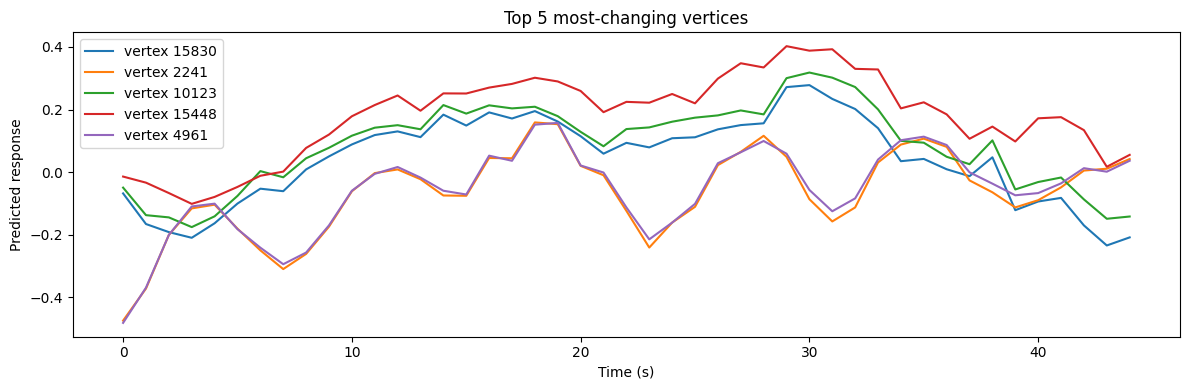

   vertex_index  variance hemisphere
0         15830  0.019307      right
1          2241  0.018324       left
2         10123  0.018066       left
3         15448  0.018060      right
4          4961  0.017870       left
5         12032  0.017383      right
6         15828  0.017307      right
7         15827  0.017220      right
8         20283  0.017219      right
9         15826  0.016747      right


In [10]:
# Cell D — Vertices that change most over time
import numpy as np, pandas as pd

vertex_var = preds.var(axis=0)                 # temporal variance per vertex
top_k = 50
top_idx = np.argsort(vertex_var)[::-1][:top_k]

top_df = pd.DataFrame({
    "vertex_index": top_idx,
    "variance": vertex_var[top_idx],
    "hemisphere": ["left" if i < n_v // 2 else "right" for i in top_idx],
})
top_df.to_csv(f"{OUT}/top_changing_vertices.csv", index=False)

# Plot time-courses of the top 5
plt.figure(figsize=(12, 4))
for i in top_idx[:5]:
    plt.plot(timestamps, preds[:, i], label=f"vertex {i}")
plt.title("Top 5 most-changing vertices"); plt.xlabel("Time (s)"); plt.ylabel("Predicted response")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT}/top_changing_vertices.png", dpi=150); plt.show()
print(top_df.head(10))

In [11]:
# Cell E — Animated brain response GIF
import numpy as np, imageio.v2 as imageio, os, matplotlib.pyplot as plt
from nilearn import datasets, plotting

fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")
half = n_v // 2

# Fixed color scale across all frames so brightness is comparable
vmax = np.percentile(np.abs(preds), 99)

# Subsample frames to keep render time reasonable (max ~60 frames)
max_frames = 60
frame_idx = np.linspace(0, n_t - 1, min(n_t, max_frames)).astype(int)

frame_dir = f"{OUT}/frames"; os.makedirs(frame_dir, exist_ok=True)
paths = []
for k, t in enumerate(frame_idx):
    fig = plotting.plot_surf_stat_map(
        fsaverage.infl_left, preds[t, :half], hemi="left",
        bg_map=fsaverage.sulc_left, vmax=vmax, colorbar=True,
        title=f"t = {timestamps[t]:.1f}s",
    )
    p = f"{frame_dir}/frame_{k:03d}.png"
    fig.savefig(p, dpi=90); plt.close(fig); paths.append(p)

images = [imageio.imread(p) for p in paths]
imageio.mimsave(f"{OUT}/brain_response.gif", images, duration=0.3)
print("Saved brain_response.gif")

Saved brain_response.gif


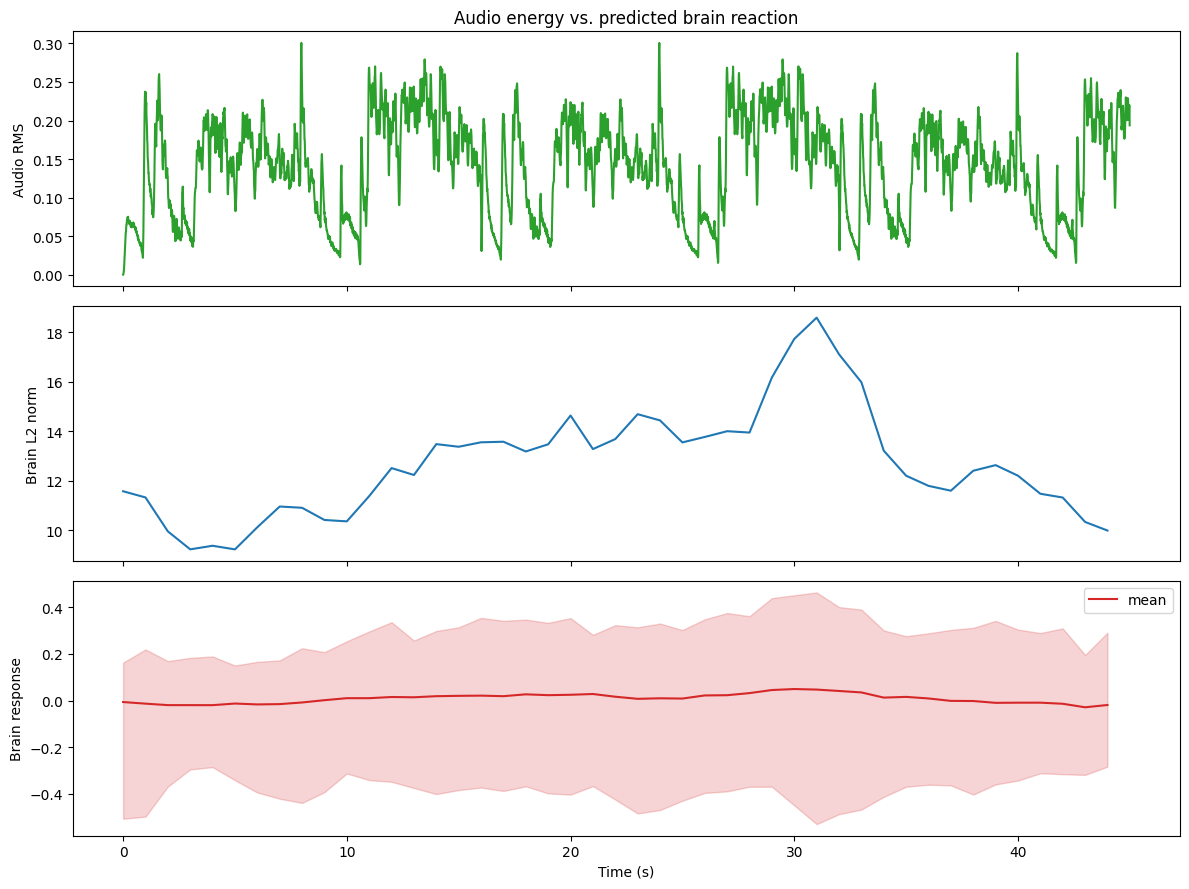

Saved summary_plots.png


In [12]:
# Cell F — Combined summary figure
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax[0].plot(rms_t, rms, color="tab:green")
ax[0].set_ylabel("Audio RMS"); ax[0].set_title("Audio energy vs. predicted brain reaction")

ax[1].plot(timestamps, metrics["l2_norm"], color="tab:blue")
ax[1].set_ylabel("Brain L2 norm")

ax[2].plot(timestamps, metrics["mean"], color="tab:red", label="mean")
ax[2].fill_between(timestamps, metrics["min"], metrics["max"], alpha=0.2, color="tab:red")
ax[2].set_ylabel("Brain response"); ax[2].set_xlabel("Time (s)"); ax[2].legend()

plt.tight_layout(); plt.savefig(f"{OUT}/summary_plots.png", dpi=150); plt.show()
print("Saved summary_plots.png")

/tmp/ipykernel_58/3070407060.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig(f"{OUT}/spatial_{name}.png", dpi=150); plt.show()


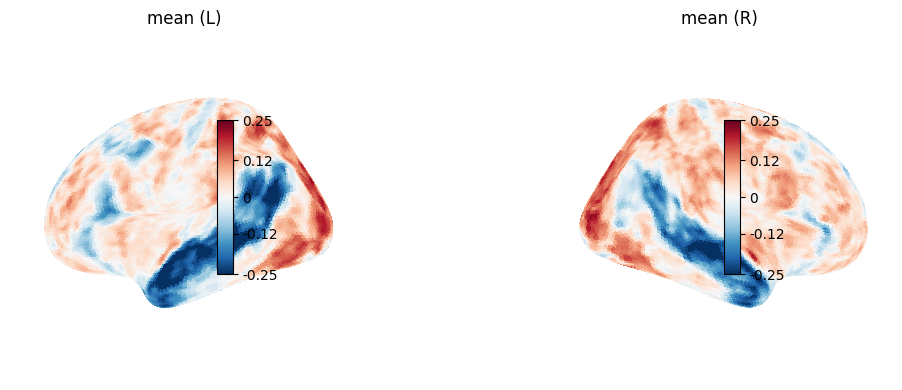

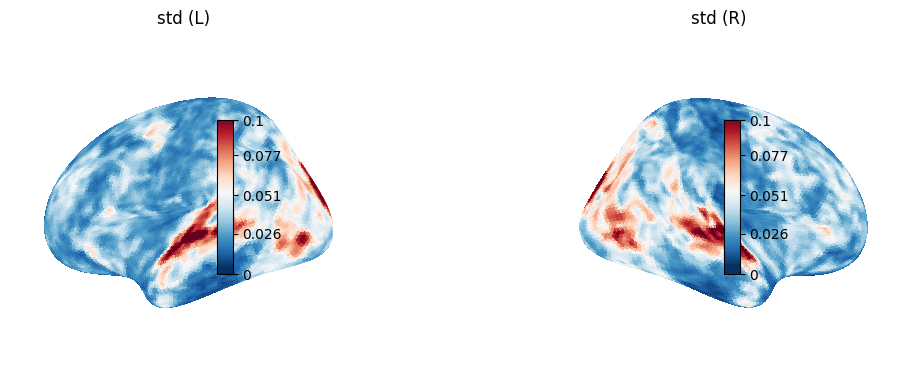

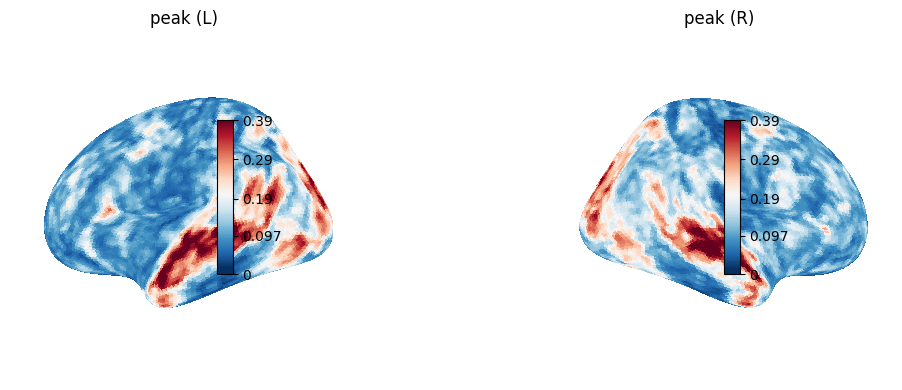

Saved spatial_mean / std / peak (.png + .npy)


In [13]:
# Cell G — Static spatial maps: mean / std / peak response across time
import numpy as np, matplotlib.pyplot as plt
from nilearn import datasets, plotting

fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")
half = n_v // 2

stat_maps = {
    "mean": preds.mean(axis=0),
    "std":  preds.std(axis=0),
    "peak": np.abs(preds).max(axis=0),
}

for name, vmap in stat_maps.items():
    vmax = np.percentile(np.abs(vmap), 99)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), subplot_kw={"projection": "3d"})
    plotting.plot_surf_stat_map(fsaverage.infl_left, vmap[:half], hemi="left",
        bg_map=fsaverage.sulc_left, vmax=vmax, colorbar=True, axes=axes[0], title=f"{name} (L)")
    plotting.plot_surf_stat_map(fsaverage.infl_right, vmap[half:], hemi="right",
        bg_map=fsaverage.sulc_right, vmax=vmax, colorbar=True, axes=axes[1], title=f"{name} (R)")
    plt.tight_layout(); plt.savefig(f"{OUT}/spatial_{name}.png", dpi=150); plt.show()
    np.save(f"{OUT}/spatial_{name}.npy", vmap)

print("Saved spatial_mean / std / peak (.png + .npy)")

[fetch_atlas_surf_destrieux] Added README.md to /root/nilearn_data

[fetch_atlas_surf_destrieux] Dataset created in /root/nilearn_data/destrieux_surface

[fetch_atlas_surf_destrieux] Downloading data from 
https://www.nitrc.org/frs/download.php/9343/lh.aparc.a2009s.annot ...

[fetch_atlas_surf_destrieux]  ...done. (0 seconds, 0 min)

[fetch_atlas_surf_destrieux] Downloading data from 
https://www.nitrc.org/frs/download.php/9342/rh.aparc.a2009s.annot ...

[fetch_atlas_surf_destrieux]  ...done. (0 seconds, 0 min)

/tmp/ipykernel_58/934924961.py:5: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_58/934924961.py:5: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()


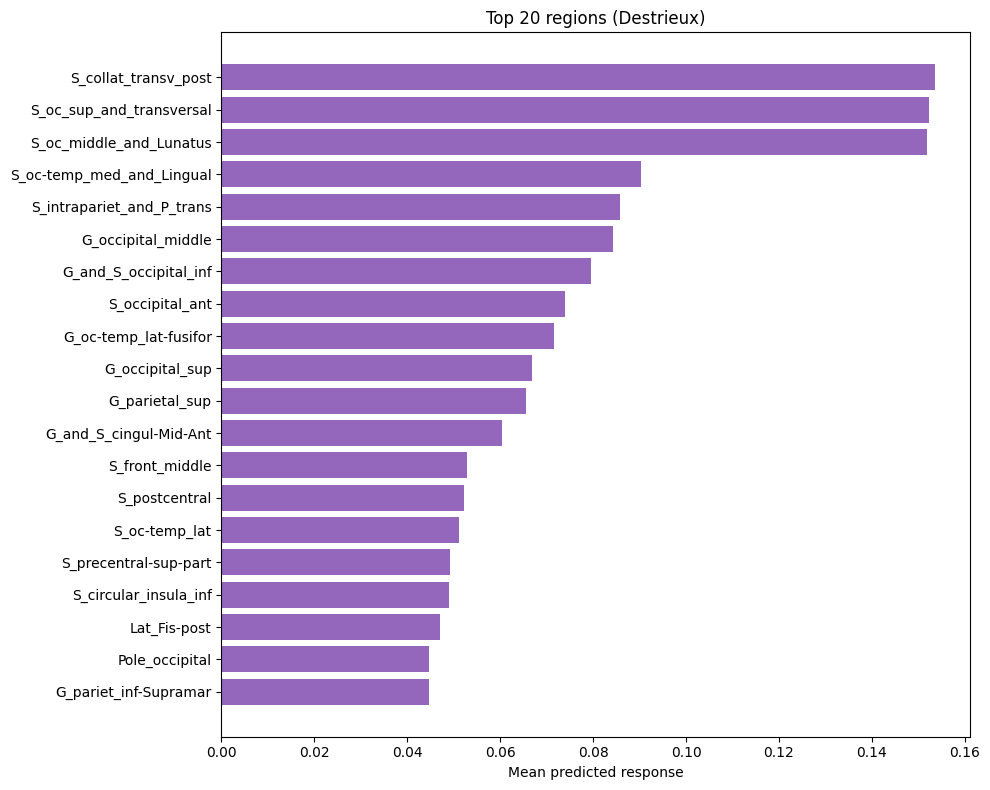

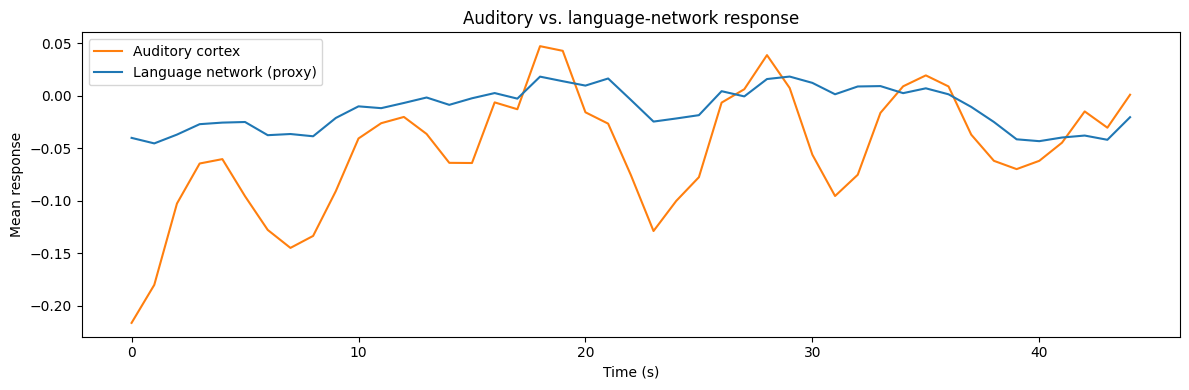

                   region  left_mean  right_mean  n_vertices  bilateral_mean
     S_collat_transv_post   0.177399    0.129605          44        0.153502
 S_oc_sup_and_transversal   0.159998    0.144637         185        0.152317
  S_oc_middle_and_Lunatus   0.160289    0.143468         120        0.151879
S_oc-temp_med_and_Lingual   0.077417    0.103277         303        0.090347
S_intrapariet_and_P_trans   0.082412    0.089258         573        0.085835
       G_occipital_middle   0.088354    0.080163         256        0.084258
    G_and_S_occipital_inf   0.092398    0.066742         153        0.079570
          S_occipital_ant   0.102228    0.045829         105        0.074029
    G_oc-temp_lat-fusifor   0.060802    0.082572         223        0.071687
          G_occipital_sup   0.046866    0.086706         187        0.066786
           G_parietal_sup   0.061794    0.069268         453        0.065531
   G_and_S_cingul-Mid-Ant   0.056381    0.064231         259        0.060306

In [14]:
# Cell H — Named-region (ROI) scorecard via Destrieux surface atlas  [RUN FIRST]
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from nilearn import datasets

destrieux = datasets.fetch_atlas_surf_destrieux()
labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux["labels"]]
map_l = np.asarray(destrieux["map_left"])
map_r = np.asarray(destrieux["map_right"])
half = n_v // 2

assert len(map_l) == half == len(map_r), \
    f"Atlas/pred mismatch: atlas={len(map_l)} preds_half={half} — vertex ordering differs, stopping."

mean_map = preds.mean(axis=0)
mean_l, mean_r = mean_map[:half], mean_map[half:]

rows = []
for idx, name in enumerate(labels):
    if name in ("Unknown", "Medial_wall"):
        continue
    lval, rval = mean_l[map_l == idx], mean_r[map_r == idx]
    rows.append({"region": name,
                 "left_mean": float(lval.mean()) if lval.size else np.nan,
                 "right_mean": float(rval.mean()) if rval.size else np.nan,
                 "n_vertices": int(lval.size + rval.size)})

roi = pd.DataFrame(rows)
roi["bilateral_mean"] = roi[["left_mean", "right_mean"]].mean(axis=1)
roi = roi.sort_values("bilateral_mean", ascending=False)
roi.to_csv(f"{OUT}/roi_scorecard_destrieux.csv", index=False)

top = roi.head(20).iloc[::-1]
plt.figure(figsize=(10, 8))
plt.barh(top["region"], top["bilateral_mean"], color="tab:purple")
plt.xlabel("Mean predicted response"); plt.title("Top 20 regions (Destrieux)")
plt.tight_layout(); plt.savefig(f"{OUT}/roi_scorecard.png", dpi=150); plt.show()

# --- Auditory cortex & language-network proxy (subsets of Destrieux) ---
auditory_labels = ["G_temp_sup-G_T_transv", "G_temp_sup-Plan_tempo",
                   "S_temporal_transverse", "G_temp_sup-Lateral"]
language_labels = ["G_front_inf-Opercular", "G_front_inf-Triangul",
                   "G_temp_sup-Lateral", "G_pariet_inf-Angular", "G_pariet_inf-Supramar"]

def region_timecourse(names):
    ids = [labels.index(n) for n in names if n in labels]
    m_l, m_r = np.isin(map_l, ids), np.isin(map_r, ids)
    tc_l = preds[:, :half][:, m_l].mean(axis=1) if m_l.any() else np.zeros(n_t)
    tc_r = preds[:, half:][:, m_r].mean(axis=1) if m_r.any() else np.zeros(n_t)
    return (tc_l + tc_r) / 2

aud_tc, lang_tc = region_timecourse(auditory_labels), region_timecourse(language_labels)
plt.figure(figsize=(12, 4))
plt.plot(timestamps, aud_tc, label="Auditory cortex", color="tab:orange")
plt.plot(timestamps, lang_tc, label="Language network (proxy)", color="tab:blue")
plt.xlabel("Time (s)"); plt.ylabel("Mean response"); plt.legend()
plt.title("Auditory vs. language-network response"); plt.tight_layout()
plt.savefig(f"{OUT}/auditory_language_timecourse.png", dpi=150); plt.show()
np.save(f"{OUT}/auditory_timecourse.npy", aud_tc); np.save(f"{OUT}/language_timecourse.npy", lang_tc)

print(roi.head(15).to_string(index=False))
print("Saved roi_scorecard(.csv/.png), auditory/language timecourses")

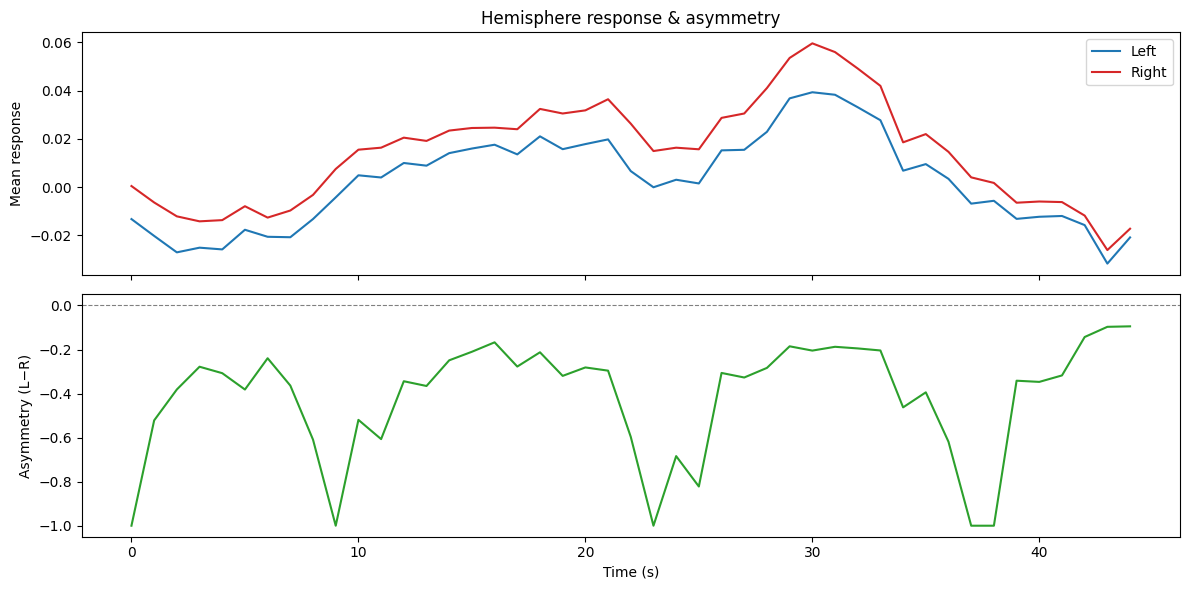

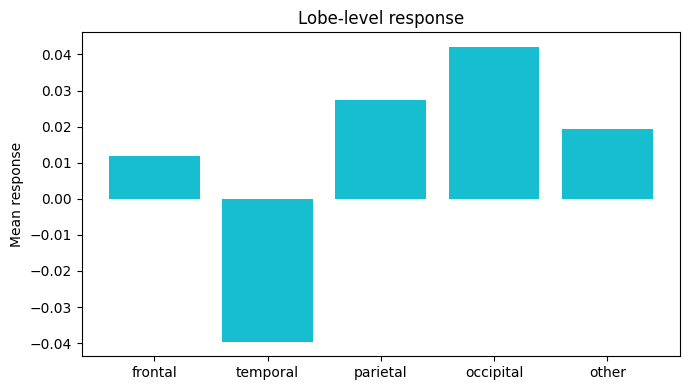

     lobe  mean_response  n_vertices
  frontal       0.011835        5070
 temporal      -0.039549        4243
 parietal       0.027325        3857
occipital       0.042049        1545
    other       0.019416        5769
Saved hemisphere_asymmetry.png, lobe_rollup(.csv/.png)


In [15]:
# Cell I — Hemisphere asymmetry + lobe-level rollups  [needs Cell H]
import numpy as np, pandas as pd, matplotlib.pyplot as plt

half = n_v // 2
left_tc, right_tc = preds[:, :half].mean(axis=1), preds[:, half:].mean(axis=1)
asym = (left_tc - right_tc) / (np.abs(left_tc) + np.abs(right_tc) + 1e-9)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(timestamps, left_tc, label="Left", color="tab:blue")
ax[0].plot(timestamps, right_tc, label="Right", color="tab:red")
ax[0].set_ylabel("Mean response"); ax[0].legend(); ax[0].set_title("Hemisphere response & asymmetry")
ax[1].plot(timestamps, asym, color="tab:green"); ax[1].axhline(0, ls="--", c="grey", lw=0.8)
ax[1].set_ylabel("Asymmetry (L−R)"); ax[1].set_xlabel("Time (s)")
plt.tight_layout(); plt.savefig(f"{OUT}/hemisphere_asymmetry.png", dpi=150); plt.show()

lobe_keywords = {
    "frontal":   ["front", "precentral", "paracentral", "rectus", "orbital", "pole_front"],
    "temporal":  ["temp", "pole_temp", "lat_fis"],
    "parietal":  ["pariet", "postcentral", "precuneus", "subparietal"],
    "occipital": ["occipital", "occ", "cuneus", "calcarine", "pole_occ"],
}
def lobe_of(name):
    low = name.lower()
    for lobe, kws in lobe_keywords.items():
        if any(k in low for k in kws):
            return lobe
    return "other"

vl = np.array([lobe_of(labels[i]) for i in map_l])
vr = np.array([lobe_of(labels[i]) for i in map_r])
mean_l, mean_r = mean_map[:half], mean_map[half:]
lobe_rows = []
for lobe in ["frontal", "temporal", "parietal", "occipital", "other"]:
    vals = np.concatenate([mean_l[vl == lobe], mean_r[vr == lobe]])
    lobe_rows.append({"lobe": lobe, "mean_response": float(vals.mean()) if vals.size else np.nan,
                      "n_vertices": int(vals.size)})
lobe_df = pd.DataFrame(lobe_rows); lobe_df.to_csv(f"{OUT}/lobe_rollup.csv", index=False)
plt.figure(figsize=(7, 4)); plt.bar(lobe_df["lobe"], lobe_df["mean_response"], color="tab:cyan")
plt.ylabel("Mean response"); plt.title("Lobe-level response"); plt.tight_layout()
plt.savefig(f"{OUT}/lobe_rollup.png", dpi=150); plt.show()
print(lobe_df.to_string(index=False)); print("Saved hemisphere_asymmetry.png, lobe_rollup(.csv/.png)")

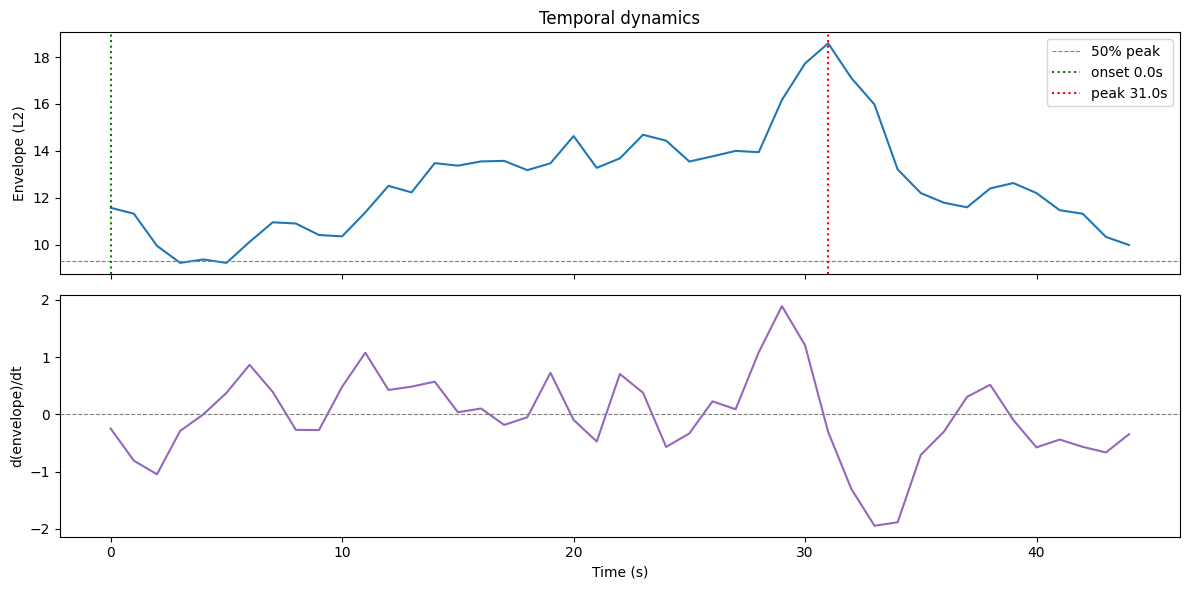

Saved temporal_dynamics.png, temporal_summary.csv


In [16]:
# Cell J — Temporal dynamics: envelope, onset/peak latency, sustain, rate-of-change
import numpy as np, pandas as pd, matplotlib.pyplot as plt

envelope = np.linalg.norm(preds, axis=1)
peak_val = envelope.max(); peak_t = timestamps[int(np.argmax(envelope))]
thresh = 0.5 * peak_val
above = np.where(envelope >= thresh)[0]
onset_t = timestamps[above[0]] if above.size else np.nan
dt = np.median(np.diff(timestamps)) if n_t > 1 else 0
sustain_s = above.size * dt
deriv = np.gradient(envelope, timestamps)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(timestamps, envelope, color="tab:blue")
ax[0].axhline(thresh, ls="--", c="grey", lw=0.8, label="50% peak")
ax[0].axvline(onset_t, ls=":", c="green", label=f"onset {onset_t:.1f}s")
ax[0].axvline(peak_t, ls=":", c="red", label=f"peak {peak_t:.1f}s")
ax[0].set_ylabel("Envelope (L2)"); ax[0].legend(); ax[0].set_title("Temporal dynamics")
ax[1].plot(timestamps, deriv, color="tab:purple"); ax[1].axhline(0, ls="--", c="grey", lw=0.8)
ax[1].set_ylabel("d(envelope)/dt"); ax[1].set_xlabel("Time (s)")
plt.tight_layout(); plt.savefig(f"{OUT}/temporal_dynamics.png", dpi=150); plt.show()

pd.DataFrame([{"peak_time_s": peak_t, "peak_value": float(peak_val), "onset_time_s": onset_t,
    "sustain_above_50pct_s": float(sustain_s), "max_pos_change": float(deriv.max()),
    "max_neg_change": float(deriv.min())}]).to_csv(f"{OUT}/temporal_summary.csv", index=False)
print("Saved temporal_dynamics.png, temporal_summary.csv")

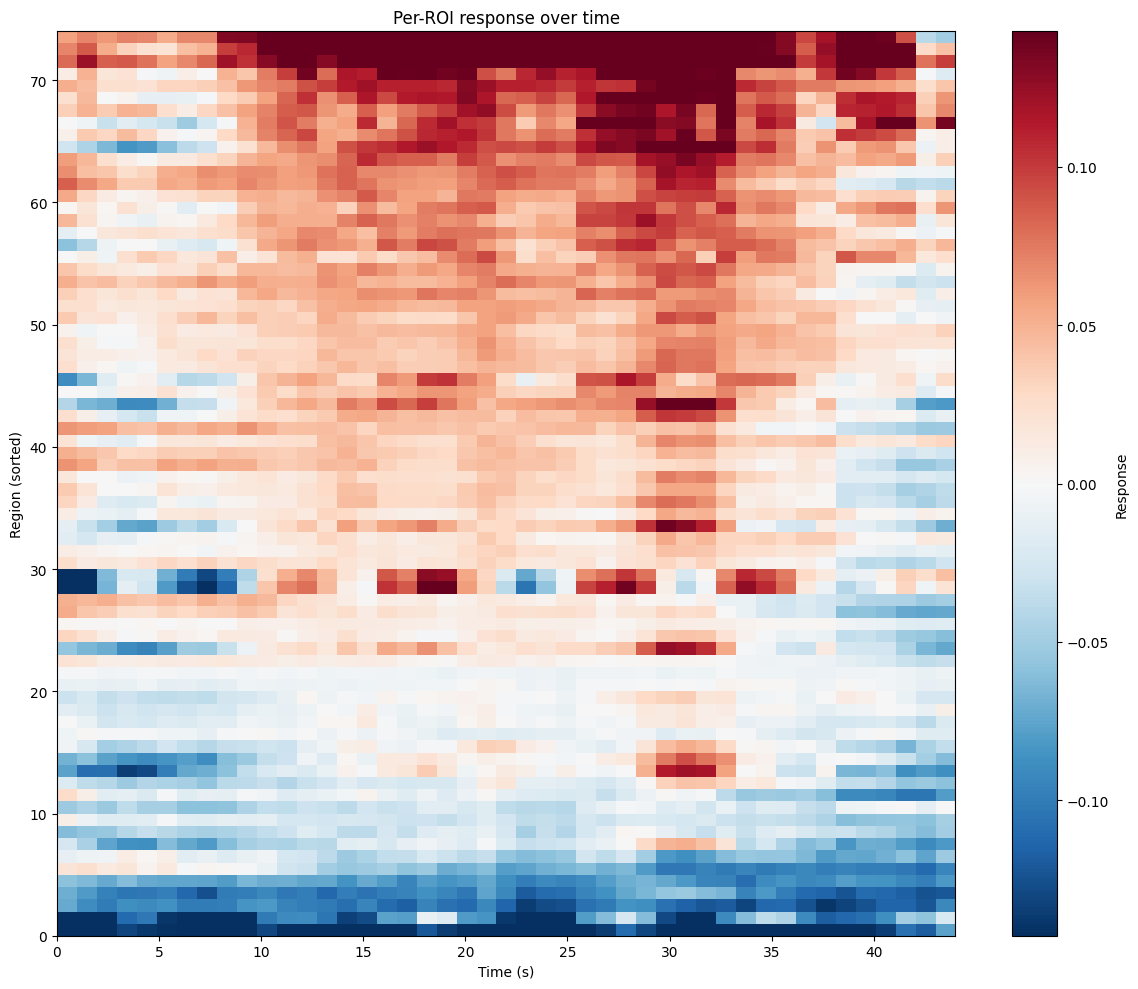

Saved roi_timecourses.csv, roi_timecourse_heatmap.png | regions: 74


In [17]:
# Cell K — Per-ROI time-courses + heatmap  [needs Cell H]
import numpy as np, pandas as pd, matplotlib.pyplot as plt

half = n_v // 2
region_names, region_tc = [], []
for idx, name in enumerate(labels):
    if name in ("Unknown", "Medial_wall"):
        continue
    m_l, m_r = (map_l == idx), (map_r == idx)
    if not (m_l.any() or m_r.any()):
        continue
    tc_l = preds[:, :half][:, m_l].mean(axis=1) if m_l.any() else 0
    tc_r = preds[:, half:][:, m_r].mean(axis=1) if m_r.any() else 0
    region_names.append(name); region_tc.append((tc_l + tc_r) / 2)
region_tc = np.array(region_tc)

pd.DataFrame(region_tc.T, columns=region_names,
             index=np.round(timestamps, 2)).to_csv(f"{OUT}/roi_timecourses.csv")
order = np.argsort(region_tc.mean(axis=1))[::-1]
lim = np.percentile(np.abs(region_tc), 95)
plt.figure(figsize=(12, 10))
plt.imshow(region_tc[order], aspect="auto", cmap="RdBu_r",
           extent=[timestamps[0], timestamps[-1], 0, len(region_names)], vmin=-lim, vmax=lim)
plt.colorbar(label="Response"); plt.xlabel("Time (s)"); plt.ylabel("Region (sorted)")
plt.title("Per-ROI response over time"); plt.tight_layout()
plt.savefig(f"{OUT}/roi_timecourse_heatmap.png", dpi=150); plt.show()
print("Saved roi_timecourses.csv, roi_timecourse_heatmap.png | regions:", len(region_names))

/tmp/ipykernel_58/1947674021.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig(f"{OUT}/corr_{name}.png", dpi=150); plt.show()


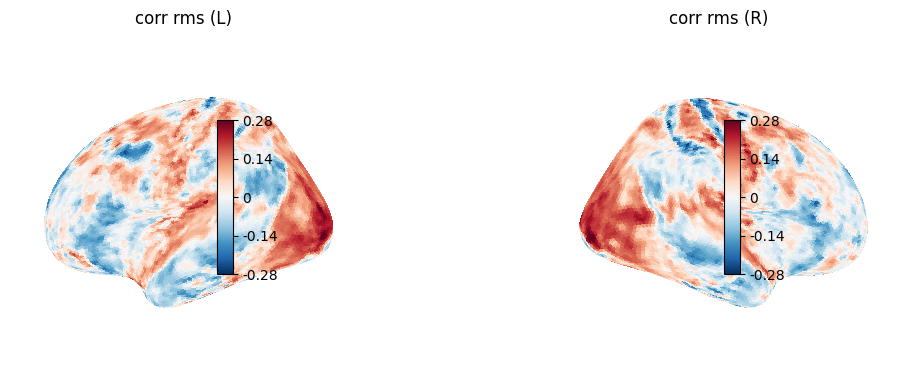

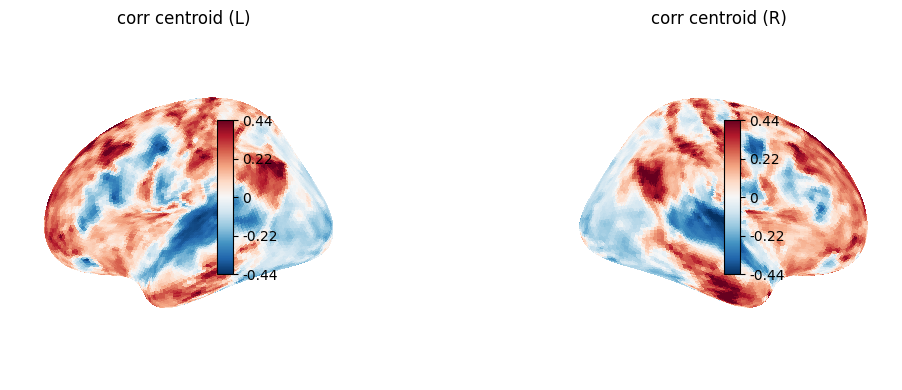

Saved corr_rms / corr_centroid (.png + .npy)


In [18]:
# Cell L — Audio feature ↔ brain correlation (per-vertex)
import numpy as np, matplotlib.pyplot as plt, librosa
from nilearn import datasets, plotting

hop = 512
rms_feat = librosa.feature.rms(y=y, hop_length=hop)[0]
cent = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hop)[0]
feat_t = librosa.frames_to_time(np.arange(len(rms_feat)), sr=sr, hop_length=hop)
rms_on_brain = np.interp(timestamps, feat_t, rms_feat)
cent_on_brain = np.interp(timestamps, feat_t, cent)

def corr_map(feature):
    f = (feature - feature.mean()) / (feature.std() + 1e-9)
    P = (preds - preds.mean(axis=0)) / (preds.std(axis=0) + 1e-9)
    return (P * f[:, None]).mean(axis=0)

r_rms, r_cent = corr_map(rms_on_brain), corr_map(cent_on_brain)
np.save(f"{OUT}/corr_rms_vertex.npy", r_rms); np.save(f"{OUT}/corr_centroid_vertex.npy", r_cent)
fsaverage = datasets.fetch_surf_fsaverage("fsaverage5"); half = n_v // 2
for name, rmap in [("rms", r_rms), ("centroid", r_cent)]:
    vmax = np.percentile(np.abs(rmap), 99)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), subplot_kw={"projection": "3d"})
    plotting.plot_surf_stat_map(fsaverage.infl_left, rmap[:half], hemi="left",
        bg_map=fsaverage.sulc_left, vmax=vmax, colorbar=True, axes=axes[0], title=f"corr {name} (L)")
    plotting.plot_surf_stat_map(fsaverage.infl_right, rmap[half:], hemi="right",
        bg_map=fsaverage.sulc_right, vmax=vmax, colorbar=True, axes=axes[1], title=f"corr {name} (R)")
    plt.tight_layout(); plt.savefig(f"{OUT}/corr_{name}.png", dpi=150); plt.show()
print("Saved corr_rms / corr_centroid (.png + .npy)")

In [20]:
# Cell M — Word / event-locked brain responses
import numpy as np, pandas as pd, matplotlib.pyplot as plt

print("Events dataframe columns:", list(df.columns))
word_col = next((c for c in ["word","text","value","token","content"] if c in df.columns), None)
onset_col = next((c for c in ["onset","start","time","onset_s","start_time"] if c in df.columns), None)
print("word_col =", word_col, "| onset_col =", onset_col)

global_tc = np.linalg.norm(preds, axis=1)
if onset_col is None:
    print("No onset column — skipping event-locked analysis. Inspect columns above and tell me the name.")
else:
    ev = df.dropna(subset=[onset_col]).copy()
    ev = ev[(ev[onset_col] >= timestamps[0]) & (ev[onset_col] <= timestamps[-1])]
    pre, post = 2.0, 6.0
    dt = np.median(np.diff(timestamps)); n_pre, n_post = int(pre/dt), int(post/dt)
    rel_t = np.arange(-n_pre, n_post) * dt
    epochs = []
    for onset in ev[onset_col].to_numpy():
        c = int(np.argmin(np.abs(timestamps - onset))); s, e = c - n_pre, c + n_post
        if s >= 0 and e <= n_t:
            epochs.append(global_tc[s:e])
    epochs = np.array(epochs)
    if epochs.size:
        m, sem = epochs.mean(axis=0), epochs.std(axis=0)/np.sqrt(len(epochs))
        plt.figure(figsize=(9, 5)); plt.plot(rel_t, m, color="tab:blue")
        plt.fill_between(rel_t, m-sem, m+sem, alpha=0.25); plt.axvline(0, ls="--", c="red", label="word onset")
        plt.xlabel("Time from word onset (s)"); plt.ylabel("Global response (L2)")
        plt.title(f"Word-locked average (n={len(epochs)} words)"); plt.legend(); plt.tight_layout()
        plt.savefig(f"{OUT}/word_locked_response.png", dpi=150); plt.show()
        np.save(f"{OUT}/word_locked_epochs.npy", epochs)
        print(f"Saved word_locked_response.png + epochs ({len(epochs)} events)")
    else:
        print("No valid epochs (words too near clip edges).")

Events dataframe columns: ['type', 'start', 'duration', 'timeline', 'subject', 'session', 'task', 'run', 'filepath', 'frequency', 'offset', 'stop', 'context']
word_col = None | onset_col = start
No valid epochs (words too near clip edges).


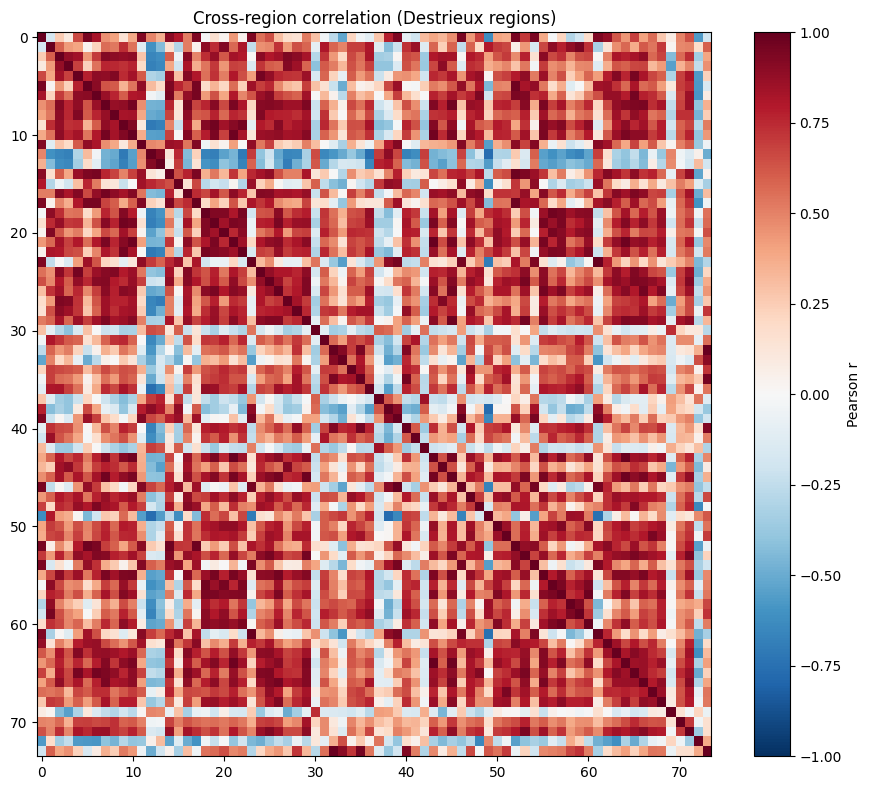

Saved region_correlation(.npy/.png) | shape: (74, 74)


In [22]:
# Cell N — Cross-region similarity (connectivity-like)  [uses Cell K's region_tc if present]
import numpy as np, matplotlib.pyplot as plt

try:
    mat, label = region_tc, "Destrieux regions"
except NameError:
    var = preds.var(axis=0); top = np.argsort(var)[::-1][:100]
    mat, label = preds[:, top].T, "Top-100 vertices"

C = np.corrcoef(mat); np.save(f"{OUT}/region_correlation_matrix.npy", C)
plt.figure(figsize=(9, 8)); plt.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Pearson r"); plt.title(f"Cross-region correlation ({label})")
plt.tight_layout(); plt.savefig(f"{OUT}/region_correlation.png", dpi=150); plt.show()
print("Saved region_correlation(.npy/.png) | shape:", C.shape)

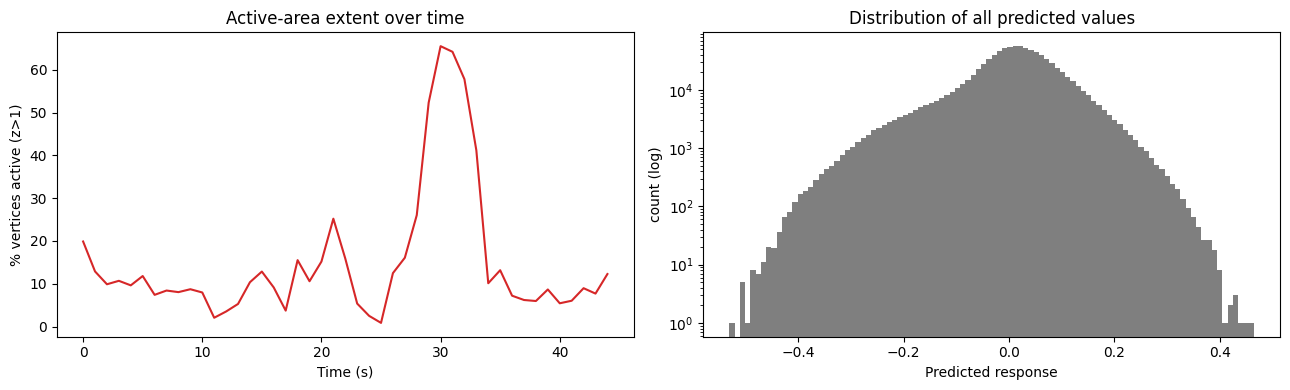

Peak extent 65.5% at t=30.0s
Saved active_extent_and_histogram.png, active_fraction.npy


In [23]:
# Cell O — Active-area extent over time + activation distribution
import numpy as np, matplotlib.pyplot as plt

baseline, sd = preds.mean(axis=0), preds.std(axis=0) + 1e-9
z = (preds - baseline) / sd
active_frac = (z > 1.0).mean(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(timestamps, active_frac*100, color="tab:red")
ax[0].set_xlabel("Time (s)"); ax[0].set_ylabel("% vertices active (z>1)")
ax[0].set_title("Active-area extent over time")
ax[1].hist(preds.ravel(), bins=100, color="tab:gray"); ax[1].set_yscale("log")
ax[1].set_xlabel("Predicted response"); ax[1].set_ylabel("count (log)")
ax[1].set_title("Distribution of all predicted values")
plt.tight_layout(); plt.savefig(f"{OUT}/active_extent_and_histogram.png", dpi=150); plt.show()
np.save(f"{OUT}/active_fraction.npy", active_frac)
print("Peak extent {:.1f}% at t={:.1f}s".format(active_frac.max()*100,
      timestamps[int(np.argmax(active_frac))]))
print("Saved active_extent_and_histogram.png, active_fraction.npy")

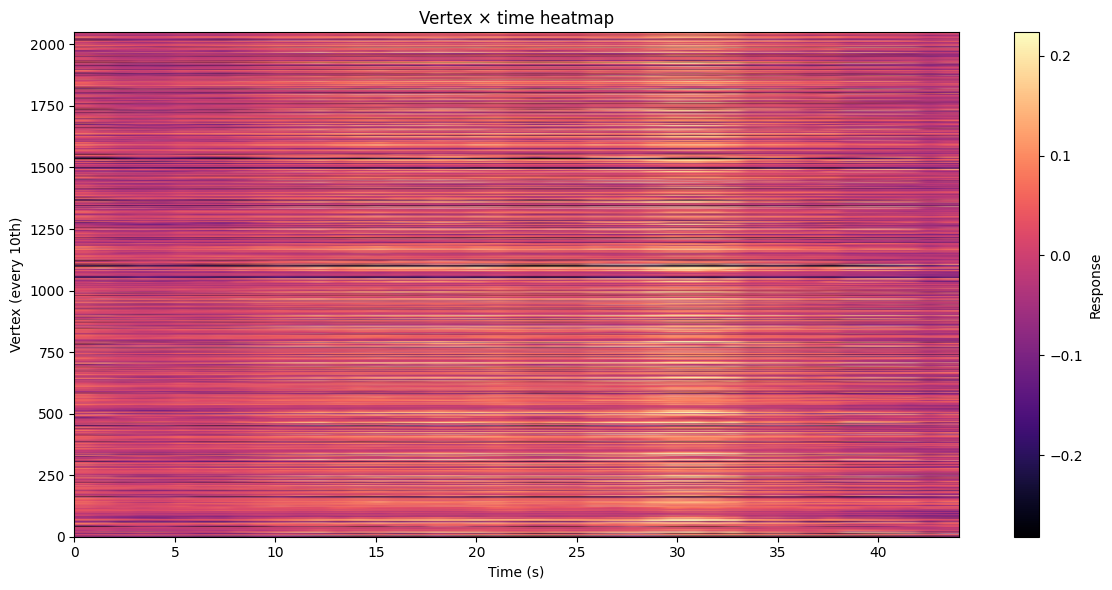

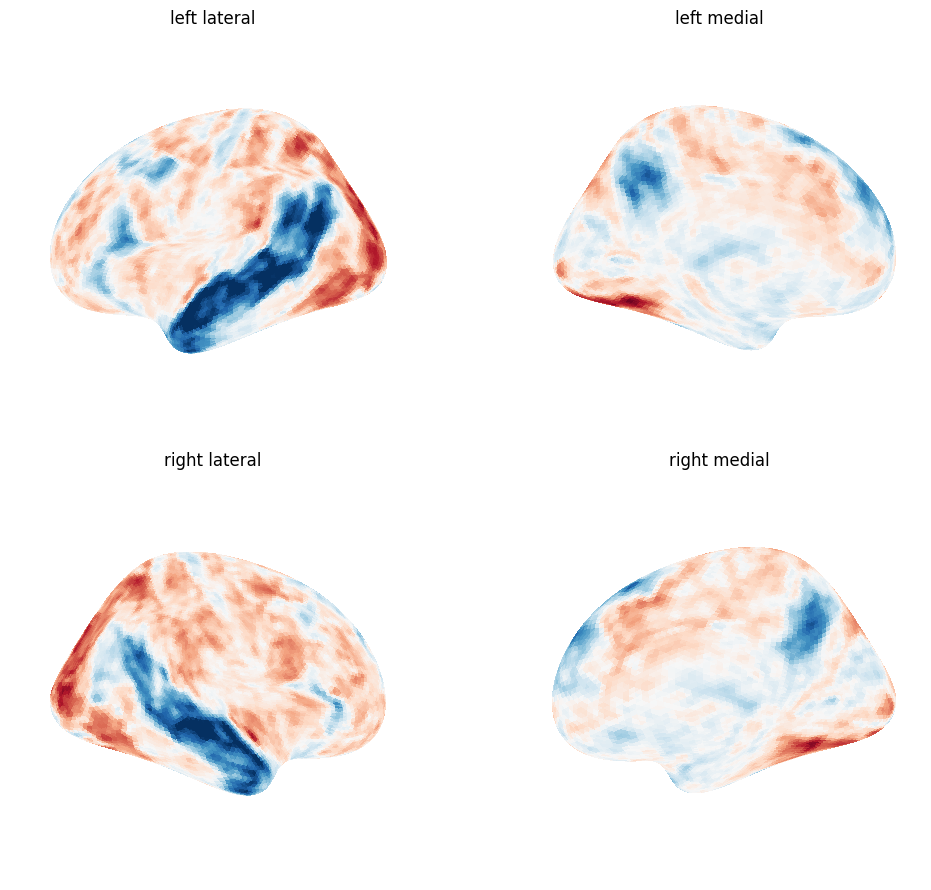

Saved vertex_time_heatmap.png, multiview_mean.png


In [24]:
# Cell P — Vertex×time heatmap + multi-view surface render
import numpy as np, matplotlib.pyplot as plt
from nilearn import datasets, plotting

step = max(1, n_v // 2000)
sub = preds[:, ::step].T
plt.figure(figsize=(12, 6))
plt.imshow(sub, aspect="auto", cmap="magma",
           extent=[timestamps[0], timestamps[-1], 0, sub.shape[0]],
           vmin=np.percentile(sub, 1), vmax=np.percentile(sub, 99))
plt.colorbar(label="Response"); plt.xlabel("Time (s)"); plt.ylabel(f"Vertex (every {step}th)")
plt.title("Vertex × time heatmap"); plt.tight_layout()
plt.savefig(f"{OUT}/vertex_time_heatmap.png", dpi=150); plt.show()

fsaverage = datasets.fetch_surf_fsaverage("fsaverage5"); half = n_v // 2
mean_map = preds.mean(axis=0); vmax = np.percentile(np.abs(mean_map), 99)
views = [("lateral","left",fsaverage.infl_left,fsaverage.sulc_left,mean_map[:half]),
         ("medial","left",fsaverage.infl_left,fsaverage.sulc_left,mean_map[:half]),
         ("lateral","right",fsaverage.infl_right,fsaverage.sulc_right,mean_map[half:]),
         ("medial","right",fsaverage.infl_right,fsaverage.sulc_right,mean_map[half:])]
fig, axes = plt.subplots(2, 2, figsize=(11, 9), subplot_kw={"projection": "3d"})
for axk, (view, hemi, mesh, bg, data) in zip(axes.ravel(), views):
    plotting.plot_surf_stat_map(mesh, data, hemi=hemi, view=view, bg_map=bg,
        vmax=vmax, colorbar=False, axes=axk, title=f"{hemi} {view}")
plt.tight_layout(); plt.savefig(f"{OUT}/multiview_mean.png", dpi=150); plt.show()
print("Saved vertex_time_heatmap.png, multiview_mean.png")